## Data Cleaning & Tidy Process

### Step 1: Load Data

The dataset is loaded using `pd.read_csv()`. Then, the first five rows of the data are displayed using `.head()`.

In [81]:
import pandas as pd
Fed_RD = pd.read_csv("data/fed_rd_year&gdp.csv")
Fed_RD.head()

,department,1976_gdp1790000000000.0,1977_gdp2028000000000.0,1978_gdp2278000000000.0,1979_gdp2570000000000.0,1980_gdp2797000000000.0,1981_gdp3138000000000.0,1982_gdp3314000000000.0,1983_gdp3541000000000.0,1984_gdp3953000000000.0,...,2008_gdp14752000000000.0,2009_gdp14415000000000.0,2010_gdp14799000000000.0,2011_gdp15379000000000.0,2012_gdp16027000000000.0,2013_gdp16516000000000.0,2014_gdp17244000000000.0,2015_gdp17983000000000.0,2016_gdp18470000000000.0,2017_gdp19177000000000.0
0,DHS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1155000000,1258000000,1009000000,848000000,527000000,737000000,1092000000,960000000,602000000,735000000
1,DOC,"819,000,000","837,000,000","871,000,000","952,000,000","945,000,000","829,000,000","693,000,000","700,000,000","755,000,000",...,1379000000,1594000000,1521000000,1357000000,1373000000,1397000000,1641000000,1596000000,1730000000,1824000000
2,DOD,"35,696,000,000","37,967,000,000","37,022,000,000","37,174,000,000","37,005,000,000","41,737,000,000","46,893,000,000","51,008,000,000","58,139,000,000",...,94247000000,93527000000,94325000000,88220000000,81543000000,70583000000,70341000000,69522000000,75213000000,51862000000
3,DOE,"10,882,000,000","13,741,000,000","15,663,000,000","15,612,000,000","15,226,000,000","14,798,000,000","12,160,000,000","11,129,000,000","11,731,000,000",...,11343000000,11823000000,12329000000,11902000000,11839000000,11528000000,12686000000,15033000000,15504000000,15032000000
4,DOT,"1,142,000,000","1,095,000,000","1,156,000,000","1,004,000,000","1,048,000,000","978,000,000","702,000,000","800,000,000","1,018,000,000",...,1016000000,1062000000,1221000000,1064000000,1007000000,881000000,843000000,926000000,910000000,936000000


### Step 2: Convert the Dataframe from Wide to Long Format

First, the dataset is reshaped from wide to long format using `pd.melt()`. At this point, `department` remains the identifier column while the original year/GDP column names are collected into one combined `year_gdp` column and the R&D values move into `gdp_value`. This is an important tidy-data step because many year-based columns are turned into one variable column that can be split and cleaned in the next steps. The first five rows of the reshaped dataset are then displayed using `.head()`.


In [82]:
# Reshape the original wide table into long format
Fed_RD = pd.melt(Fed_RD, id_vars = ['department'], var_name = 'year_gdp', value_name = 'gdp_value')
Fed_RD.head()

,department,year_gdp,gdp_value
0,DHS,1976_gdp1790000000000.0,NaN
1,DOC,1976_gdp1790000000000.0,"819,000,000"
2,DOD,1976_gdp1790000000000.0,"35,696,000,000"
3,DOE,1976_gdp1790000000000.0,"10,882,000,000"
4,DOT,1976_gdp1790000000000.0,"1,142,000,000"


### Step 3: Split Combined Variables and Drop Unneeded Column

The combined `year_gdp` column is split into two separate variables, `year` and `gdp`, using `str.split()`, and the original `year_gdp` column is then dropped. This matters for tidy data because each variable should be stored in its own column rather than being combined inside one text field.

In [83]:
# Split the combined year and GDP label into separate variables
Fed_RD[['year', 'gdp']] = Fed_RD['year_gdp'].str.split('_', expand=True)
Fed_RD = Fed_RD.drop(columns=['year_gdp'])
Fed_RD.head()

,department,gdp_value,year,gdp
0,DHS,NaN,1976,gdp1790000000000.0
1,DOC,"819,000,000",1976,gdp1790000000000.0
2,DOD,"35,696,000,000",1976,gdp1790000000000.0
3,DOE,"10,882,000,000",1976,gdp1790000000000.0
4,DOT,"1,142,000,000",1976,gdp1790000000000.0


### Step 4: Remove Extra Text

`str.replace()` removes the text `"gdp"` from the GDP field so that the values can be converted into clean numeric data later. This step removes extra string information that would interfere with analysis and helps complete the process of separating each variable into its own usable column.

In [84]:
# Remove the text so GDP can become a numeric field
Fed_RD['gdp'] = Fed_RD['gdp'].str.replace('gdp', '')
Fed_RD.head()

,department,gdp_value,year,gdp
0,DHS,NaN,1976,1790000000000.0
1,DOC,"819,000,000",1976,1790000000000.0
2,DOD,"35,696,000,000",1976,1790000000000.0
3,DOE,"10,882,000,000",1976,1790000000000.0
4,DOT,"1,142,000,000",1976,1790000000000.0


### Step 5: Rename Columns

The columns are renamed to `Department`, `RD_Budget`, `Year`, and `GDP` to make them easier to read.

In [85]:
Fed_RD = Fed_RD.rename(columns={'department': 'Department', 'year': 'Year', 'gdp_value': 'RD_Budget', 'gdp': 'GDP'})
Fed_RD.head()

,Department,RD_Budget,Year,GDP
0,DHS,NaN,1976,1790000000000.0
1,DOC,"819,000,000",1976,1790000000000.0
2,DOD,"35,696,000,000",1976,1790000000000.0
3,DOE,"10,882,000,000",1976,1790000000000.0
4,DOT,"1,142,000,000",1976,1790000000000.0


### Step 6: Convert Columns to Numeric Format

Then `Year`, `RD_Budget` and `GDP` are converted to numeric format, and the display format is changed so the values appear as regular numbers instead of scientific notation. Also, this change allows for better analysis and visuals moving forward.

In [86]:
# Convert the cleaned variables to numeric form for analysis
Fed_RD['Year'] = pd.to_numeric(Fed_RD['Year'])
Fed_RD['RD_Budget'] = pd.to_numeric(Fed_RD['RD_Budget'])
Fed_RD['GDP'] = pd.to_numeric(Fed_RD['GDP'])

# Set display format for better readability
pd.options.display.float_format = '{:,.0f}'.format
Fed_RD.head()

,Department,RD_Budget,Year,GDP
0,DHS,NaN,1976,"1,790,000,000,000"
1,DOC,"819,000,000",1976,"1,790,000,000,000"
2,DOD,"35,696,000,000",1976,"1,790,000,000,000"
3,DOE,"10,882,000,000",1976,"1,790,000,000,000"
4,DOT,"1,142,000,000",1976,"1,790,000,000,000"


### Step 7: Reorder Columns

Finally, the columns are reordered to a logical structure (`Department`, `Year`, `RD_Budget`, `GDP`), resulting in a clean and well-organized dataset that is ready for analysis. In the final tidy table, each variable is in its own column, each row represents one department-year observation, and the dataset contains one observational unit: federal department R&D spending by year. These steps follow the tidy data principles from the Tidy Data reading, and functions such as `melt()`, `str.split()`, and `pivot_table()` connect directly to tools shown in the Pandas Cheat Sheet.

In [87]:
Fed_RD = Fed_RD[['Department', 'Year', 'RD_Budget', 'GDP']]
Fed_RD

,Department,Year,RD_Budget,GDP
0,DHS,1976,NaN,"1,790,000,000,000"
1,DOC,1976,"819,000,000","1,790,000,000,000"
2,DOD,1976,"35,696,000,000","1,790,000,000,000"
3,DOE,1976,"10,882,000,000","1,790,000,000,000"
4,DOT,1976,"1,142,000,000","1,790,000,000,000"
...,...,...,...,...
583,NIH,2017,"33,052,000,000","19,177,000,000,000"
584,NSF,2017,"6,040,000,000","19,177,000,000,000"
585,Other,2017,"1,553,000,000","19,177,000,000,000"
586,USDA,2017,"2,625,000,000","19,177,000,000,000"


## Exploratory Data Analysis

After cleaning the dataset into tidy format, the following visuals explore how federal R&D spending changed over time and how dominant the Department of Defense remained compared with other major departments.

### Visual 1: DOD Compared with the Next Largest R&D Departments

This chart focuses on the Department of Defense and compares it with HHS and NIH, the two departments that come closest to it in later years. Instead of showing every department at once, this visual narrows the story to the biggest players. It shows that DOD remained the largest federal R&D spender throughout the dataset, but the gap between DOD and the health-related departments became smaller over time.

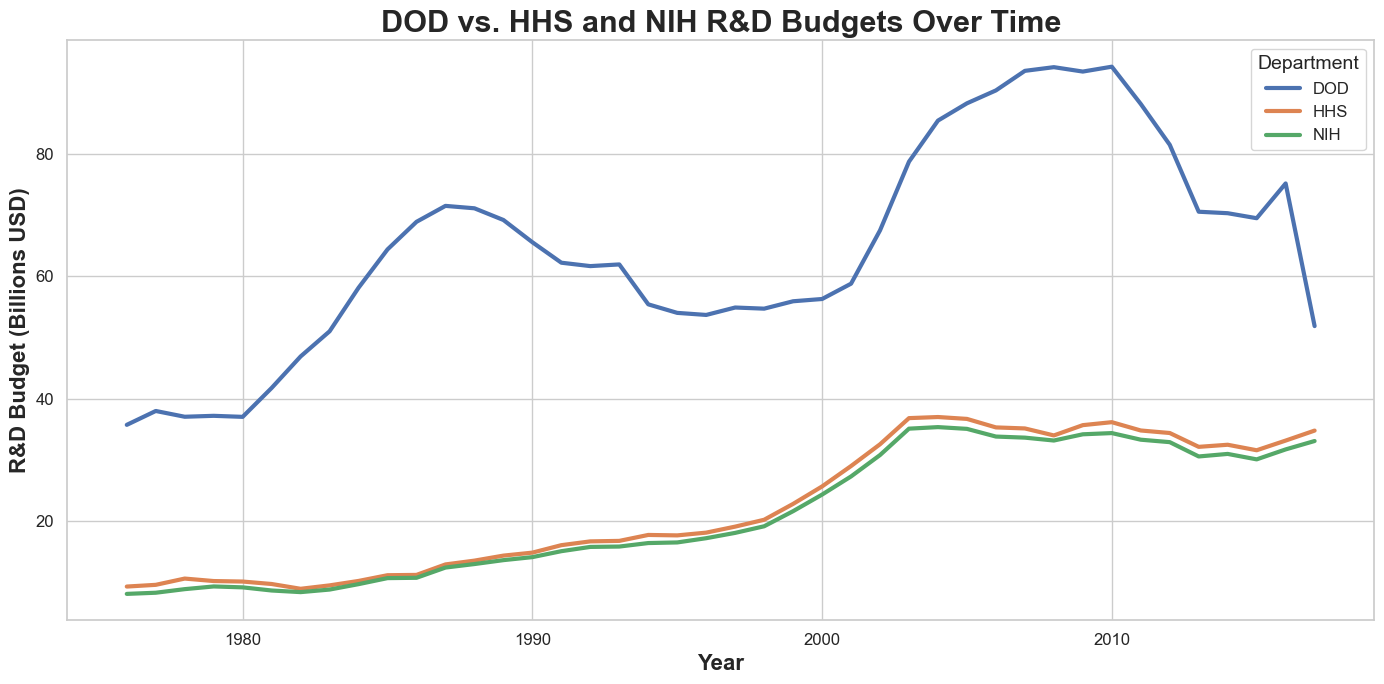

In [101]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

# Focus the comparison on DOD and the departments that come closest to it in spending
story_departments = ['DOD', 'HHS', 'NIH']
story_df = Fed_RD[Fed_RD['Department'].isin(story_departments)].copy()
story_df['RD_Budget_Billions'] = story_df['RD_Budget'] / 1e9

plt.figure(figsize=(14, 7))
ax = sns.lineplot(data=story_df, x='Year', y='RD_Budget_Billions', hue='Department', linewidth=3)
plt.title('DOD vs. HHS and NIH R&D Budgets Over Time', fontsize=22, weight='bold')
plt.xlabel('Year', fontsize=16, weight = 'bold')
plt.ylabel('R&D Budget (Billions USD)', fontsize=16, weight = 'bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Department', fontsize=12, title_fontsize=14)
plt.tight_layout()
plt.show()

### Visual 2: How Much of Federal R&D Was Controlled by DOD?

This visual looks at DOD's share of the total federal R&D budget each year. That makes the chart more analytical than a simple budget line because it shows how dominant DOD was relative to the rest of the federal government. The pattern shows that DOD controlled a very large share early on and still led by 2017, but its portion of total federal R&D was less overwhelming by the end of the period.

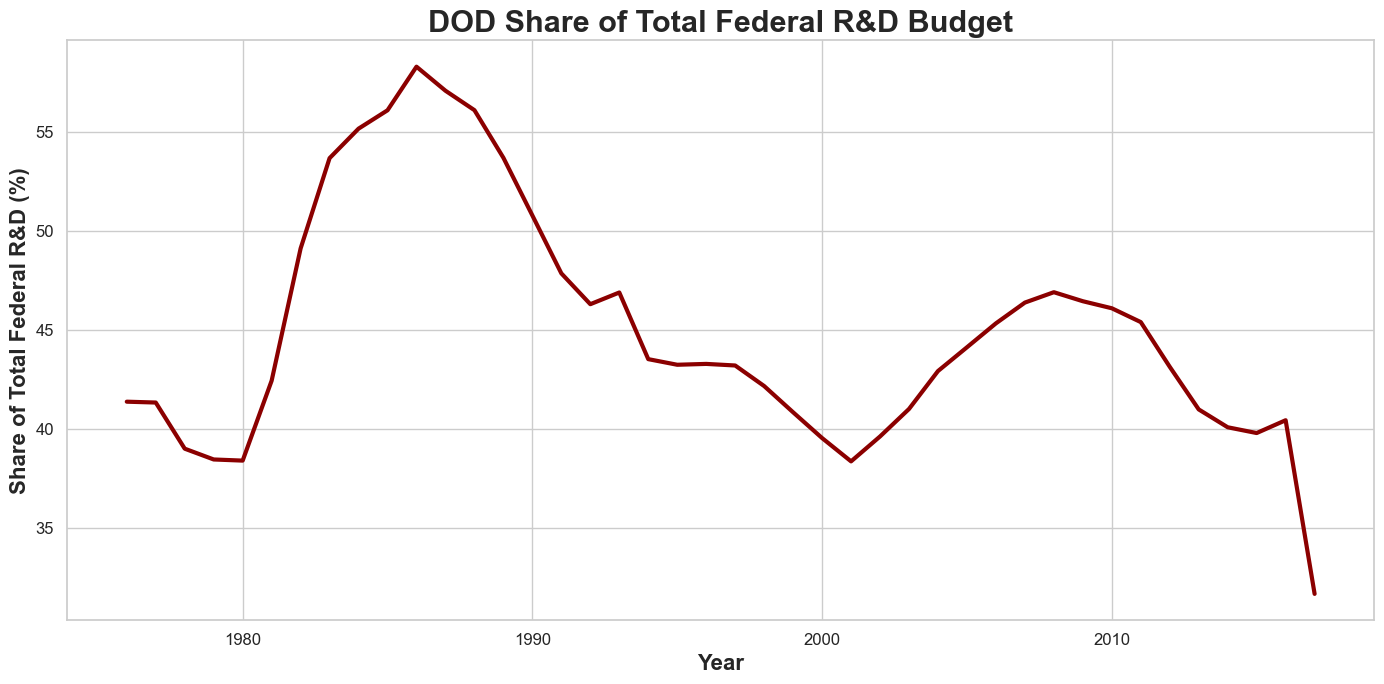

In [102]:
# Compare DOD to the total federal R&D budget each year
yearly_total_rd = Fed_RD.groupby('Year')['RD_Budget'].sum().rename('Total_RD')
dod_share = Fed_RD[Fed_RD['Department'] == 'DOD'].merge(yearly_total_rd, on='Year')
dod_share['SharePct'] = (dod_share['RD_Budget'] / dod_share['Total_RD']) * 100

plt.figure(figsize=(14, 7))
ax = sns.lineplot(data=dod_share, x='Year', y='SharePct', color='darkred', linewidth=3)
plt.title('DOD Share of Total Federal R&D Budget', fontsize=22, weight='bold')
plt.xlabel('Year', fontsize=16, weight = 'bold')
plt.ylabel('Share of Total Federal R&D (%)', fontsize=16, weight = 'bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

### Visual 3: Where DOD Stood Relative to Other Departments in the Latest Year

Instead of another time-series graph, this chart compares departments in the most recent year of the dataset using R&D budget as a share of GDP. This gives a clearer snapshot of how large DOD's research spending was relative to the economy and shows whether it still stood apart from the other major departments by the end of the period.

C:\Users\tommy\AppData\Local\Temp\ipykernel_17668\1377740407.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=latest_df, y='Department', x='RD_as_GDP_Pct', palette=palette)


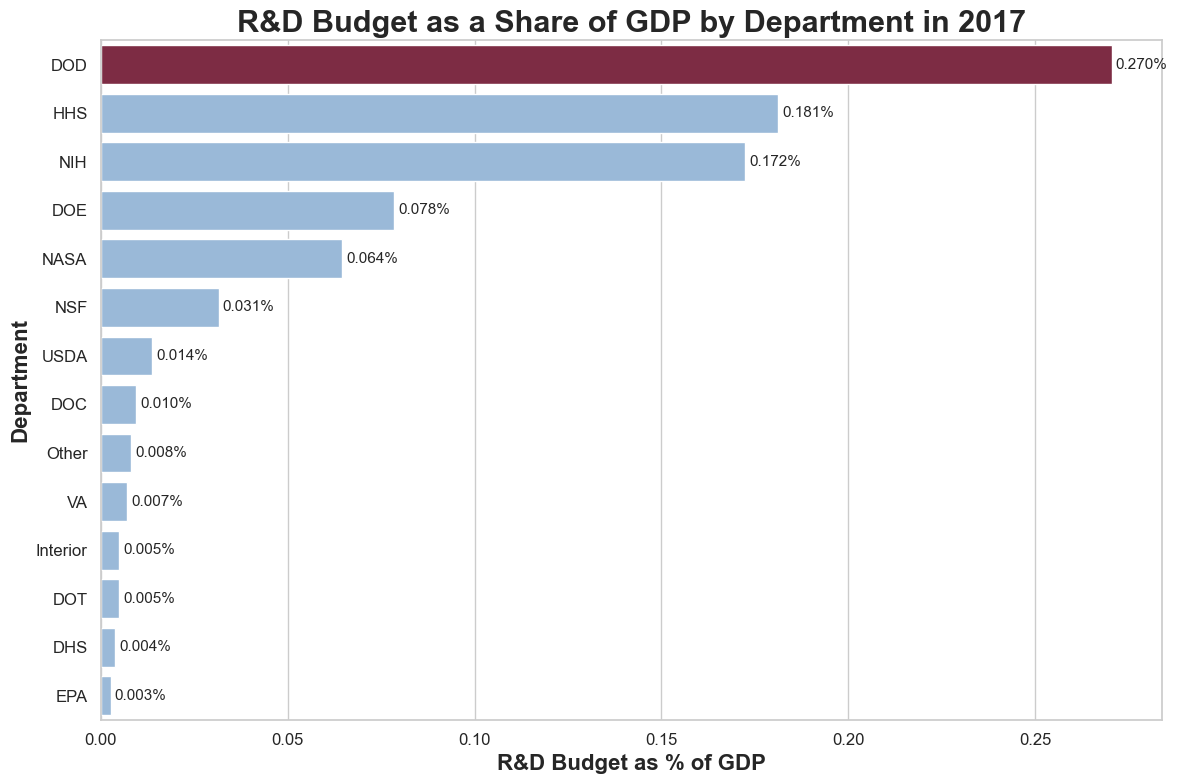

In [103]:
# Use the most recent year as a final comparison snapshot across departments
latest_year = Fed_RD['Year'].max()
latest_df = Fed_RD[Fed_RD['Year'] == latest_year].copy()
latest_df['RD_as_GDP_Pct'] = (latest_df['RD_Budget'] / latest_df['GDP']) * 100
latest_df = latest_df.sort_values('RD_as_GDP_Pct', ascending=False)

plt.figure(figsize=(12, 8))
palette = ['#8B1E3F' if dept == 'DOD' else '#8FB9E3' for dept in latest_df['Department']]
ax = sns.barplot(data=latest_df, y='Department', x='RD_as_GDP_Pct', palette=palette)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f%%', fontsize=11, padding=3)
plt.title(f'R&D Budget as a Share of GDP by Department in {latest_year}', fontsize=22, weight='bold')
plt.xlabel('R&D Budget as % of GDP', fontsize=16, weight = 'bold')
plt.ylabel('Department', fontsize=16, weight = 'bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

### Pivot Table: Average R&D Budget by Department

This pivot table calculates the average R&D budget for each department across all years. The data is grouped by department and the mean R&D spending is computed, then sorted from highest to lowest spending. The Department of Defense (DOD) has the highest average R&D budget, significantly exceeding all other departments. In contrast, departments such as Veterans Affairs (VA) have much lower average spending.

In [91]:
# Create pivot table to analyze average R&D budget by department
pivot_table_RD = pd.pivot_table(
    Fed_RD,
    values='RD_Budget',
    index='Department',
    aggfunc='mean'
).sort_values(by='RD_Budget', ascending=False)

pivot_table_RD

,RD_Budget
Department,
DOD,"64,685,190,476"
HHS,"22,296,761,905"
NIH,"21,117,571,429"
NASA,"12,140,261,905"
DOE,"11,883,380,952"
NSF,"4,038,809,524"
USDA,"2,380,809,524"
Other,"1,494,761,905"
DOC,"1,231,500,000"
